## Task 1: Data Exploration & Visualization


### 1.0 Dataset Overview
#### 1.1 Load Required Libraries

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


#### 1.2 Load Dataset

In [136]:
# Load dataset
df = pd.read_csv("Spotify dataset export 2025-12-31 15-24-26.csv")

# Display basic info
df.shape


(20594, 24)

This shows that there are 20594 rows (songs) and 24 columns (attributes).

#### 1.3 Preview Dataset

In [137]:
# View first 5 rows
df.head()


,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221,6220896,169907,True,True,1040234854,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645,1079128,31003,True,True,310083733,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055,282142,7399,True,True,63063467,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952,1788577,55229,True,True,434663559,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958,6197318,155930,True,True,617259738,9.942693,Youtube


In [138]:
# View column names
df.columns


Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Title', 'Channel',
       'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream',
       'EnergyLiveness', 'most_playedon'],
      dtype='object')

In [139]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20594 entries, 0 to 20593
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Artist            20594 non-null  object 
 1   Track             20594 non-null  object 
 2   Album             20594 non-null  object 
 3   Album_type        20594 non-null  object 
 4   Danceability      20594 non-null  float64
 5   Energy            20594 non-null  float64
 6   Loudness          20594 non-null  float64
 7   Speechiness       20594 non-null  float64
 8   Acousticness      20594 non-null  float64
 9   Instrumentalness  20594 non-null  float64
 10  Liveness          20594 non-null  float64
 11  Valence           20594 non-null  float64
 12  Tempo             20594 non-null  float64
 13  Duration_min      20594 non-null  float64
 14  Title             20594 non-null  object 
 15  Channel           20594 non-null  object 
 16  Views             20594 non-null  int64 

### 2.0 Dataset Overview (Schema + Meaning)
#### 2.1 Overview

This dataset contains structured information about Spotify songs, including:
- Song metadata (artist, album, channel)
- Audio characteristics extracted from Spotify
- Engagement and popularity metrics
- Platform and licensing indicators

Each row represents one song.

#### 2.2 Column Type Summary Table

In [140]:
# Create column summary table
column_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Example Value": [df[col].iloc[0] for col in df.columns]
})

column_summary


,Column Name,Data Type,Example Value
0,Artist,object,Gorillaz
1,Track,object,Feel Good Inc.
2,Album,object,Demon Days
3,Album_type,object,album
4,Danceability,float64,0.818
5,Energy,float64,0.705
6,Loudness,float64,-6.679
7,Speechiness,float64,0.177
8,Acousticness,float64,0.00836
9,Instrumentalness,float64,0.00233


#### 2.3 Count by Data Type

In [141]:
df.dtypes.value_counts()


float64    11
object      7
int64       4
bool        2
Name: count, dtype: int64

### 3.0 Data Quality Checks

This section checks for missing values, duplicates, and basic data validity to ensure the dataset is reliable for downstream analysis.


#### 3.1 Missing Values Check
Missing values were examined at two levels:

1. Technical missing values, represented by NaN values.
2. Semantic missing values, where placeholder strings such as "0", empty strings,
   or textual null indicators are used instead of NaN.

This distinction is important because semantic missing values are not detected by
standard missing-value checks.


In [142]:
# 1. Technical missing values (NaN)
technical_missing = df.isnull().sum()
technical_missing


Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      0
most_playedon       0
dtype: int64

**Observation:**
No explicit NaN values are present in the dataset.


In [143]:
# 2. Semantic missing values in categorical columns
categorical_cols = [
    "Artist", "Track", "Album", "Album_type",
    "Title", "Channel", "most_playedon"
]

semantic_placeholders = ["0", "", "none", "nan", "null"]

semantic_missing_counts = {
    col: df[col].astype(str).str.strip().str.lower().isin(semantic_placeholders).sum()
    for col in categorical_cols
}

semantic_missing_df = pd.DataFrame.from_dict(
    semantic_missing_counts,
    orient="index",
    columns=["Semantic Missing Count"]
)

semantic_missing_df


,Semantic Missing Count
Artist,0
Track,0
Album,0
Album_type,0
Title,469
Channel,469
most_playedon,0


In [144]:
missing_summary = pd.DataFrame({
    "NaN Count": df[categorical_cols].isnull().sum(),
    "Semantic Missing Count": semantic_missing_df["Semantic Missing Count"]
})

missing_summary


,NaN Count,Semantic Missing Count
Artist,0,0
Track,0,0
Album,0,0
Album_type,0,0
Title,0,469
Channel,0,469
most_playedon,0,0


**Observation:**

- The Title and Channel columns both contain 469 semantic missing values.
- This suggests that these missing entries originate from the same subset of records,
  likely corresponding to tracks without associated channel or title metadata.
- These values are represented using placeholder strings rather than NaN values.


#### 3.2 Duplicate Records Check (Artist + Track)

In [145]:
# Check duplicates based on Artist + Track
duplicate_mask = df.duplicated(subset=["Artist", "Track"], keep=False)

duplicates_df = df[duplicate_mask]

duplicates_df.shape


(163, 24)

#### 3.2.1 Duplicate Count Summary

In [146]:
# Count number of duplicated song entries
duplicate_count = duplicates_df.groupby(["Artist", "Track"]).size().reset_index(name="Count")

duplicate_count.sort_values("Count", ascending=False)


,Artist,Track,Count
9,Blackstreet,No Diggity,3
0,Ananya Bhat,Mehabooba,2
1,Antonio Orozco,Entre Sobras Y Sobras Me Faltas,2
3,Aretha Franklin,Think,2
2,Antonio Orozco,Mi Héroe,2
...,...,...,...
76,Whitney Houston,How Will I Know,2
77,Yiruma,River Flows In You,2
78,Yoko Ono,Give Peace A Chance - Ultimate Mix,2
79,Zé Ramalho,Chão de Giz,2


#### 3.2.2 Sample of Duplicated Songs

In [147]:
# Show example duplicated records
duplicates_df[["Artist", "Track", "Album", "Channel", "most_playedon"]]


,Artist,Track,Album,Channel,most_playedon
772,Whitney Houston,How Will I Know,I Wanna Dance With Somebody (The Movie: Whitne...,whitneyhoustonVEVO,Youtube
773,Whitney Houston,How Will I Know,Whitney Houston,whitneyhoustonVEVO,Spotify
1578,Scorpions,Still Loving You,Comeblack,Scorpions,Spotify
1581,Scorpions,No One Like You,Blackout,Scorpions,Youtube
1582,Scorpions,Still Loving You,Love At First Sting,Scorpions,Youtube
...,...,...,...,...,...
18906,Soolking,Suavemente,Suavemente,Soolking Officiel,Youtube
18966,Beret,Vuelve,FANTASÍA,SebastianYatraVEVO,Youtube
18970,Beret,Vuelve,Prisma,SebastianYatraVEVO,Youtube
20465,João Gomes,Dengo,Digo Ou Não Digo,João Gomes Cantor,Spotify


#### 3.3 Basic Validity & Range Checks
##### 3.3.1 Audio Features Expected in [0, 1]
The following audio features are expected to have values between 0 and 1:
- Danceability
- Energy
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence


In [148]:
audio_01_features = [
    "Danceability", "Energy", "Speechiness",
    "Acousticness", "Instrumentalness",
    "Liveness", "Valence"
]

df[audio_01_features].describe()


,Danceability,Energy,Speechiness,Acousticness,Instrumentalness,Liveness,Valence
count,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000,20594.000000
mean,0.620102,0.635176,0.096733,0.291391,0.056162,0.193653,0.530077
std,0.165504,0.214274,0.112182,0.286117,0.193622,0.168832,0.245542
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.519000,0.507000,0.035700,0.045200,0.000000,0.094100,0.340000
50%,0.638000,0.666000,0.050650,0.193000,0.000002,0.125000,0.538000
75%,0.741000,0.798000,0.104000,0.476750,0.000474,0.237000,0.727000
max,0.975000,1.000000,0.964000,0.996000,1.000000,1.000000,0.993000


**Observation:**

- All listed audio features fall within the expected [0, 1] range.
- This confirms they are already normalized and suitable for similarity calculations.


##### 3.3.2 Loudness Range Check
Loudness values are expected to be negative, measured in decibels (dB).

In [149]:
df["Loudness"].describe()


count    20594.000000
mean        -7.678254
std          4.639481
min        -46.251000
25%         -8.868000
50%         -6.540500
75%         -4.935000
max          0.920000
Name: Loudness, dtype: float64

**Observation:**

- Loudness values are predominantly negative, which is consistent with audio engineering standards.
- A small number of near-zero or slightly positive values are observed, which can occur due to mastering differences.

##### 3.3.3 Engagement Metrics Non-Negativity Check
Engagement metrics should not contain negative values:
- Views
- Likes
- Comments
- Stream


In [150]:
engagement_features = ["Views", "Likes", "Comments", "Stream"]

(df[engagement_features] < 0).sum()


Views       0
Likes       0
Comments    0
Stream      0
dtype: int64

**Observation:**

- No negative values are found in engagement-related metrics.
- This confirms the validity of popularity indicators.


#####  3.4 Summary of Data Quality Findings
**Key Findings:**

- No technical missing values (NaN) were detected in the dataset.
- Semantic missing values were identified in selected categorical attributes, particularly Title and Channel, where placeholder strings are used instead of NaN.
- Duplicate songs exist when considering Artist + Track combinations.
- Audio features fall within valid and expected ranges.
- Engagement metrics are non-negative and valid.


### 4.0 Engagement Metrics Analysis
Engagement and popularity metrics in music datasets are typically highly skewed.
In this section, both raw and log-transformed distributions are analyzed to better
understand the spread and scale of user engagement.

#### 4.1 Engagement Metrics Considered
The following engagement metrics are analyzed:

- Views  
- Likes  
- Comments  
- Stream  

These variables often contain extreme values, especially for highly popular songs.


In [151]:
engagement_features = ["Views", "Likes", "Comments", "Stream"]


#### To better visualize skewed distributions, a log10(1 + x) transformation is applied.
This transformation preserves ordering while reducing the impact of extreme values.


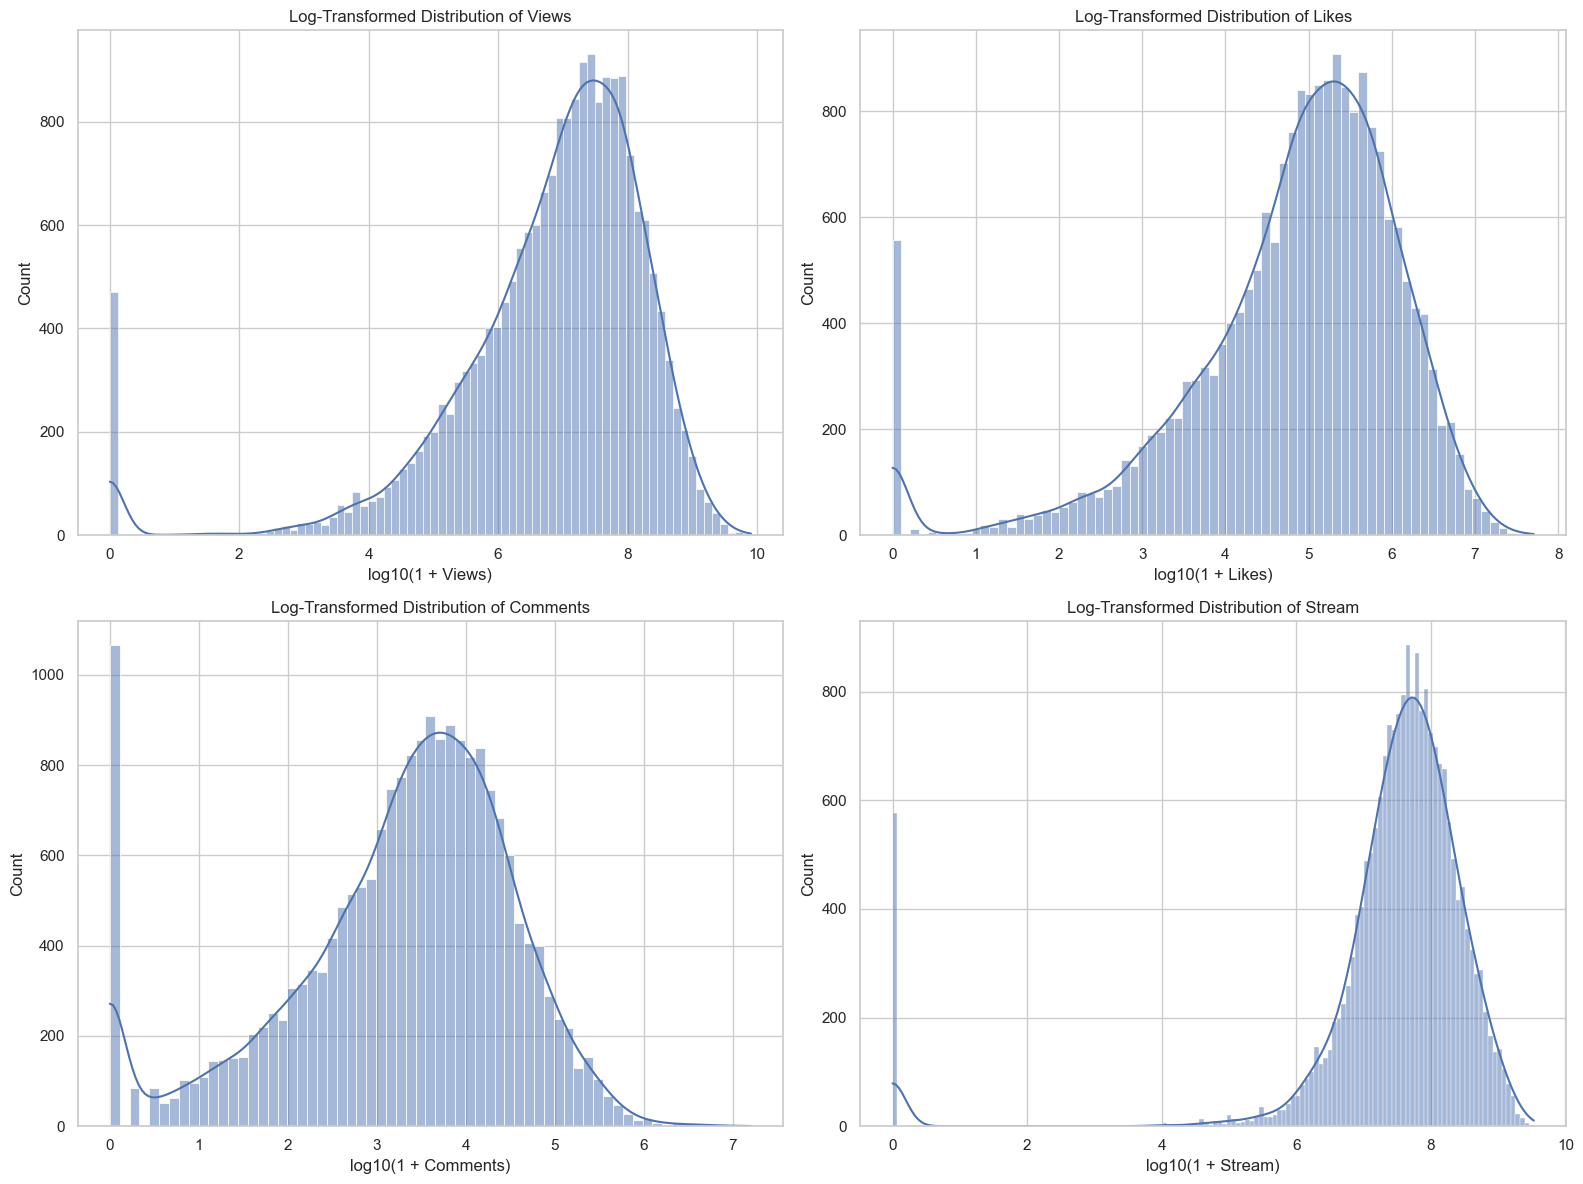

In [152]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(engagement_features):
    sns.histplot(np.log10(1 + df[feature]), kde=True, ax=axes[i])
    axes[i].set_title(f"Log-Transformed Distribution of {feature}")
    axes[i].set_xlabel(f"log10(1 + {feature})")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Observation:**

- Log transformation reveals clearer distribution patterns.
- Most songs fall within a moderate engagement range.
- This transformation is suitable for downstream similarity and analysis.
- Engagement metrics are extremely skewed.
- Log transformation is essential for meaningful visualization.


#### 4.2 Boxplots on Log Scale
Boxplots using log-transformed values help identify outliers and spread more clearly.


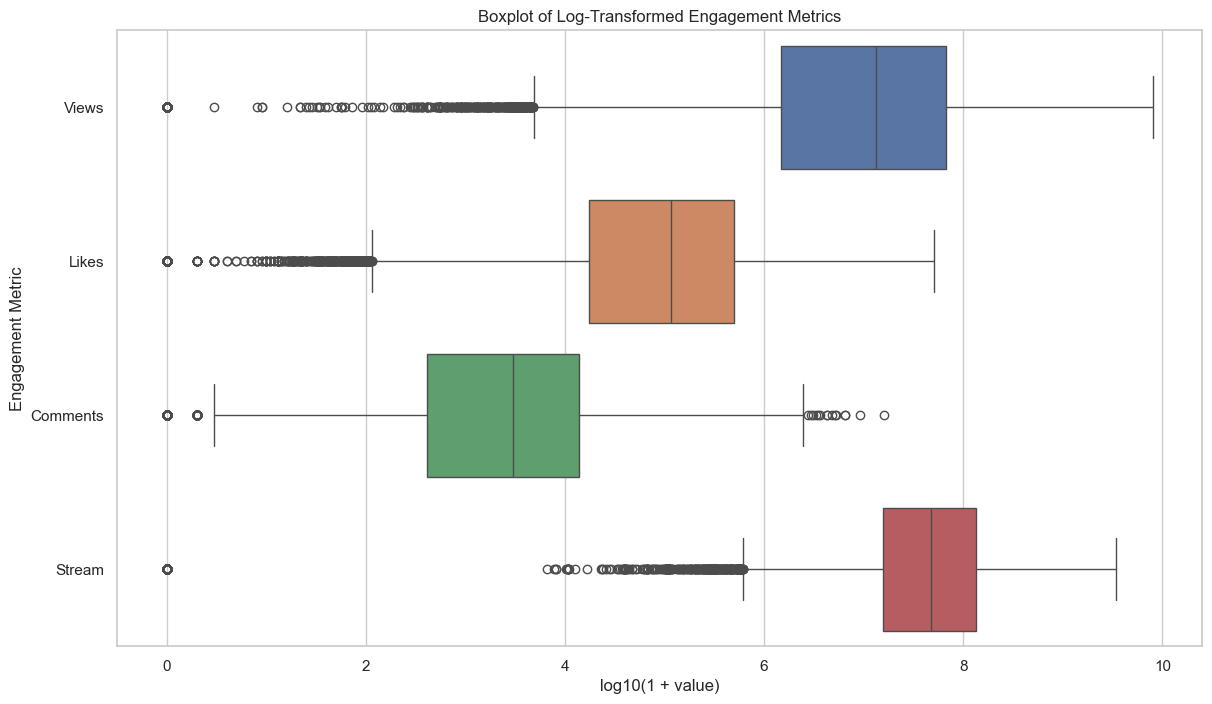

In [153]:
log_engagement_df = df[engagement_features].apply(lambda x: np.log10(1 + x))

plt.figure(figsize=(14, 8))
sns.boxplot(data=log_engagement_df, orient="h")
plt.title("Boxplot of Log-Transformed Engagement Metrics")
plt.xlabel("log10(1 + value)")
plt.ylabel("Engagement Metric")
plt.show()


**Observation:**

- Significant outliers remain, especially for Comments and Stream.
- Log scaling reduces but does not eliminate extreme popularity effects.


### 5.0 Data Distribution

#### 5.1 Top 20 Songs by Stream
The following bar chart highlights the most-streamed songs in the dataset.


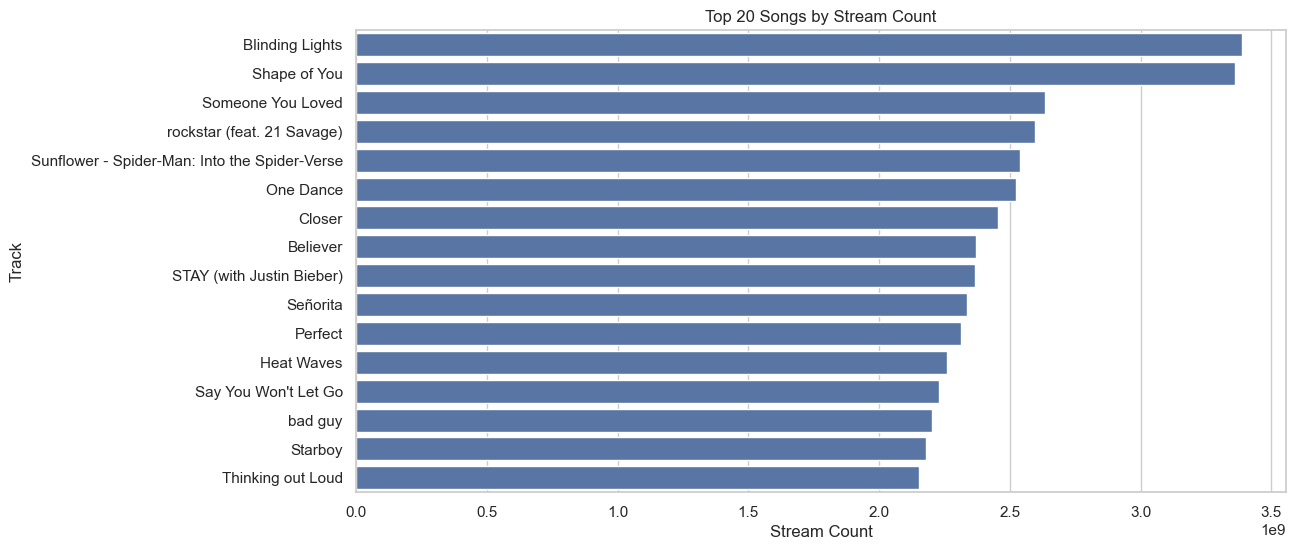

In [154]:
top_streamed = df.sort_values("Stream", ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_streamed,
    x="Stream",
    y="Track",
    orient="h"
)
plt.title("Top 20 Songs by Stream Count")
plt.xlabel("Stream Count")
plt.ylabel("Track")
plt.show()


#### 5.2 Album Type Distribution


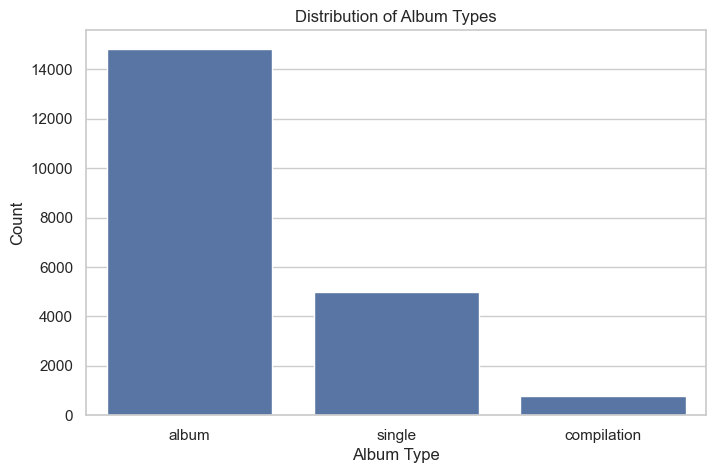

In [155]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Album_type")
plt.title("Distribution of Album Types")
plt.xlabel("Album Type")
plt.ylabel("Count")
plt.show()


#### 5.3 Platform Distribution (Most Played On)

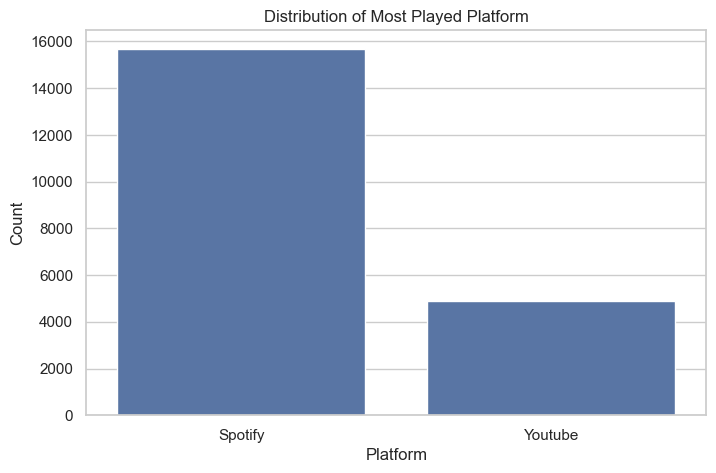

In [156]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="most_playedon")
plt.title("Distribution of Most Played Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.show()


#### 5.4 Licensed vs Unlicensed Content

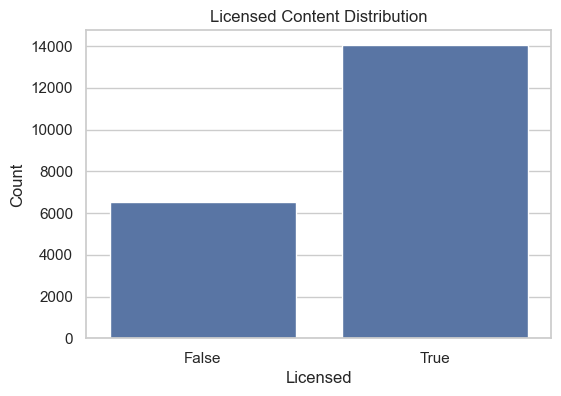

In [157]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Licensed")
plt.title("Licensed Content Distribution")
plt.xlabel("Licensed")
plt.ylabel("Count")
plt.show()


#### 5.5 Official Video Distribution

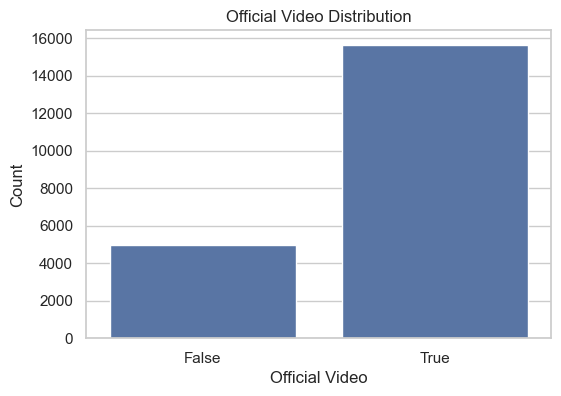

In [158]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="official_video")
plt.title("Official Video Distribution")
plt.xlabel("Official Video")
plt.ylabel("Count")
plt.show()


#### 5.6 Top 15 Artists by Number of Tracks

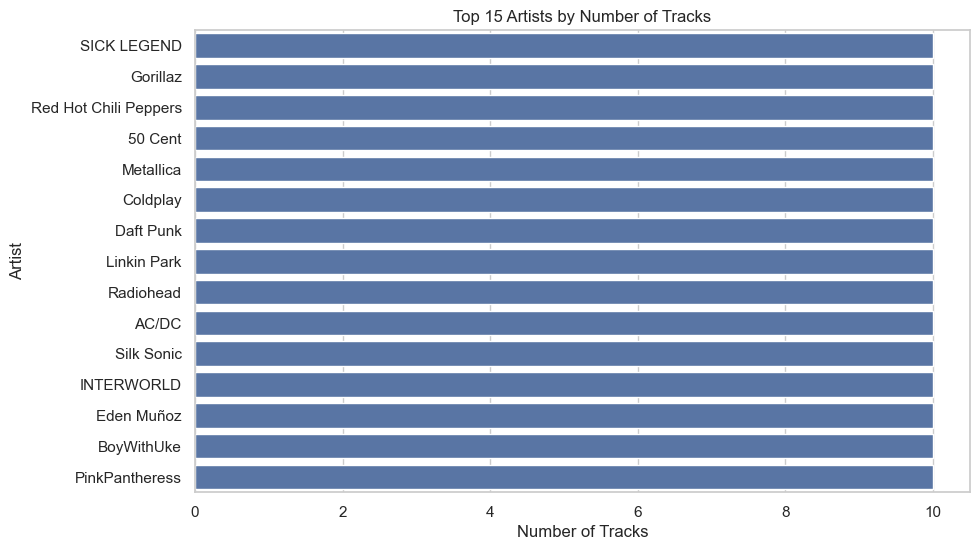

In [159]:
top_artists = df["Artist"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Top 15 Artists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")
plt.show()


#### 5.7 Top 15 Channels by Number of Tracks

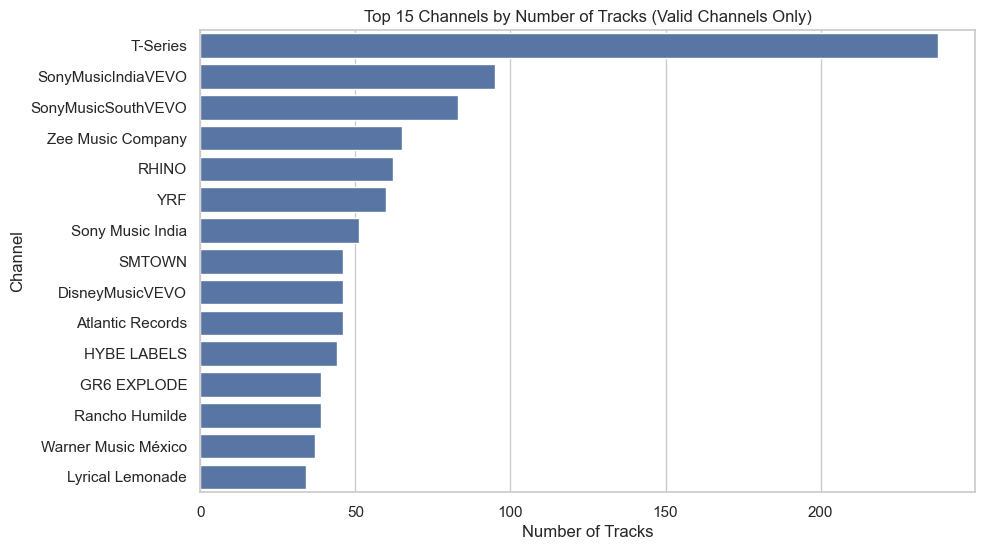

In [160]:
# Exclude invalid channel placeholders (semantic missing values)
valid_channels = df[
    df["Channel"].astype(str).str.strip() != "0"
]

top_channels = valid_channels["Channel"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_channels.values, y=top_channels.index)
plt.title("Top 15 Channels by Number of Tracks (Valid Channels Only)")
plt.xlabel("Number of Tracks")
plt.ylabel("Channel")
plt.show()


Note: Invalid placeholder channel values ("0") were excluded from this visualization
to improve interpretability.


### 6.0 Relationship Exploration (Bivariate Analysis)
Bivariate analysis explores relationships between pairs of variables to identify
patterns that cannot be observed through univariate analysis alone.
This section focuses on correlations and pairwise relationships between
audio features and engagement metrics.


#### 6.1 Correlation Analysis (Numerical Features)
A correlation heatmap is used to examine linear relationships among numerical
audio features and engagement metrics.


In [161]:
numerical_features = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness", "Valence",
    "Tempo", "Duration_min",
    "Views", "Likes", "Comments", "Stream",
    "EnergyLiveness"
]


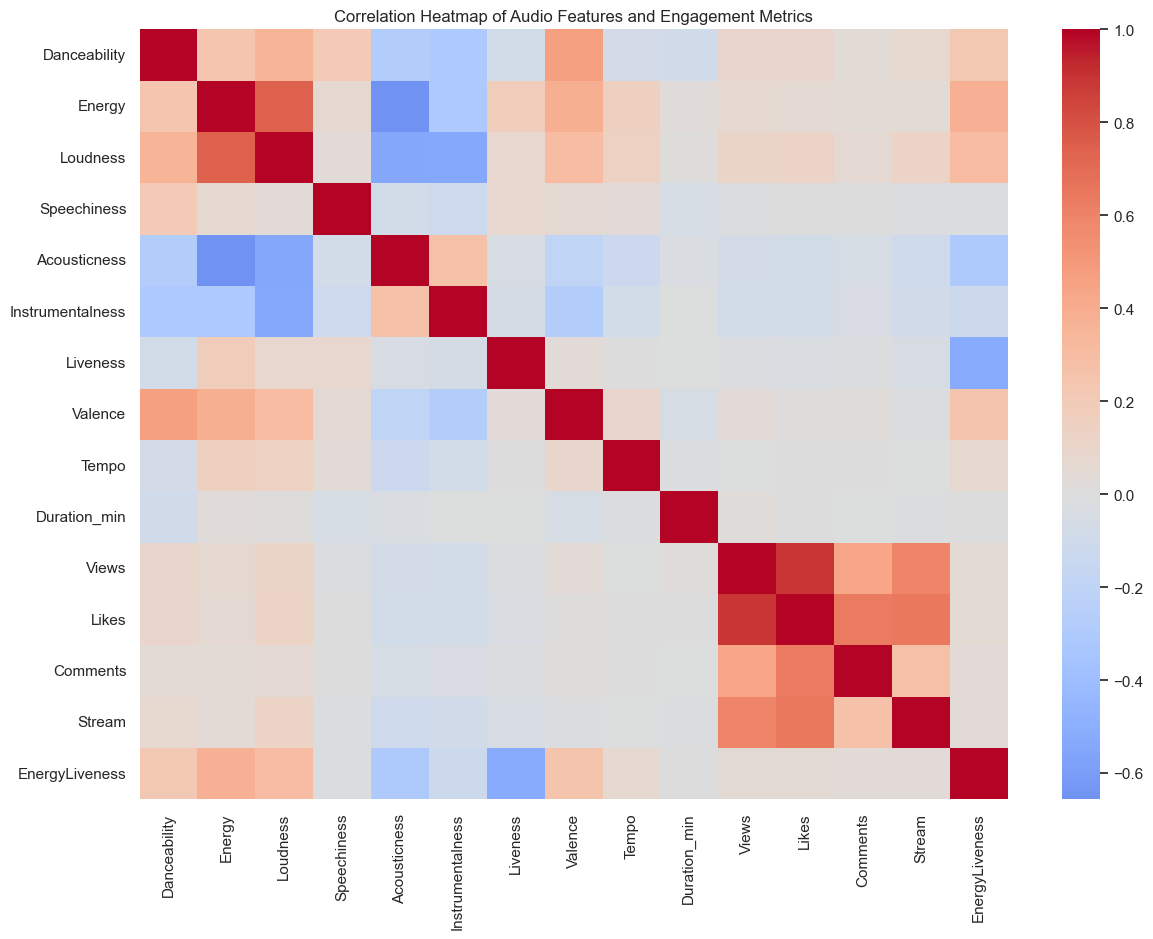

In [162]:
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Audio Features and Engagement Metrics")
plt.show()


**Key Observations:**

- Strong positive correlation exists between Views and Likes.
- Engagement metrics (Views, Likes, Comments, Stream) are strongly correlated
  with one another.
- Audio features generally show weak correlations with engagement metrics,
  suggesting that popularity is not directly driven by individual audio attributes.


#### 6.2 Engagement Metric Relationships
Scatter plots are used to further examine relationships between engagement metrics.
Due to heavy skewness, a log1p (log(1 + x)) transformation is applied.

##### 6.2.1 Views vs Likes

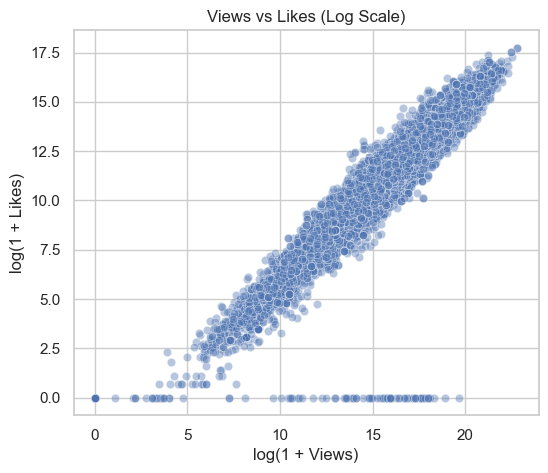

In [163]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=np.log1p(df["Views"]),
    y=np.log1p(df["Likes"]),
    alpha=0.4
)
plt.title("Views vs Likes (Log Scale)")
plt.xlabel("log(1 + Views)")
plt.ylabel("log(1 + Likes)")
plt.show()

##### 6.2.2 Stream vs Views

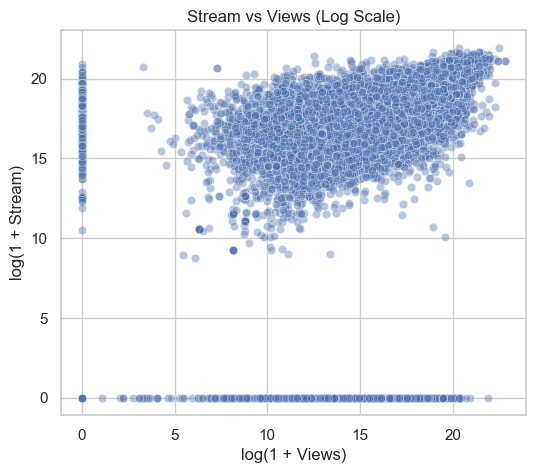

In [164]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=np.log1p(df["Views"]),
    y=np.log1p(df["Stream"]),
    alpha=0.4
)
plt.title("Stream vs Views (Log Scale)")
plt.xlabel("log(1 + Views)")
plt.ylabel("log(1 + Stream)")
plt.show()


##### 6.2.3 Stream vs Likes

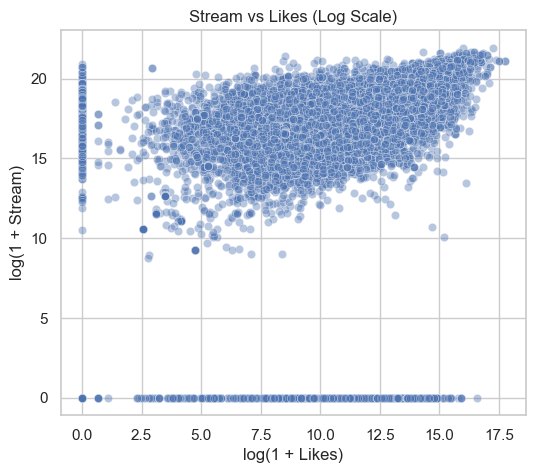

In [165]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=np.log1p(df["Likes"]),
    y=np.log1p(df["Stream"]),
    alpha=0.4
)
plt.title("Stream vs Likes (Log Scale)")
plt.xlabel("log(1 + Likes)")
plt.ylabel("log(1 + Stream)")
plt.show()


**Observation:**

- Engagement metrics show strong positive, approximately linear relationships
  after log transformation.
- This confirms consistent popularity patterns across platforms.


#### 7.0 Group Comparison Analysis
Group comparison analysis examines how audio features and engagement metrics
vary across different categorical groups.
This provides interpretability and supports application-level insights.


#### 7.1 Audio Features by Platform (most_playedon)
This analysis investigates whether songs primarily played on Spotify and YouTube
exhibit different audio characteristics.


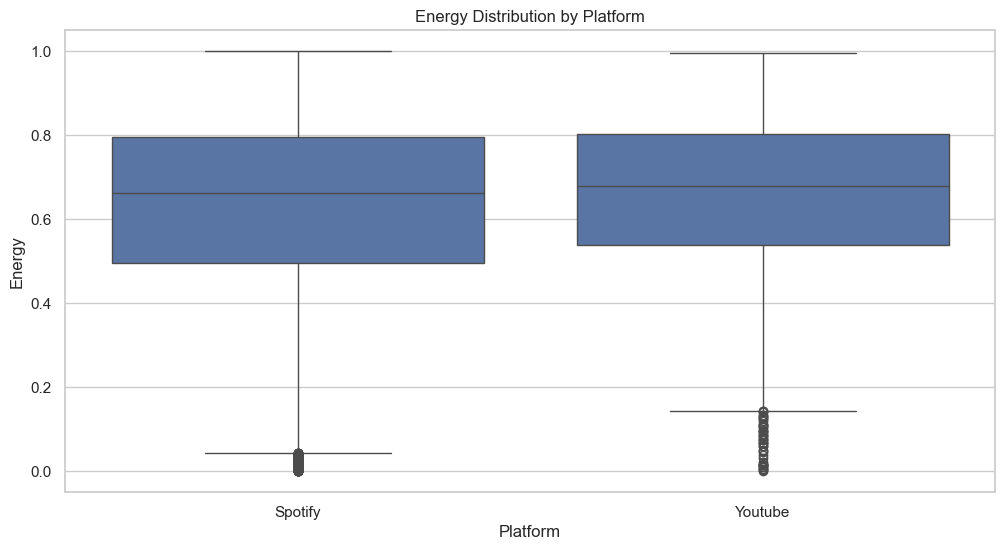

In [166]:
audio_subset = [
    "Danceability", "Energy", "Acousticness", "Valence"
]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="most_playedon",
    y="Energy"
)
plt.title("Energy Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Energy")
plt.show()


#### 7.2 Engagement Metrics by Official Video Status
This analysis examines whether songs with official videos tend to receive
higher engagement.


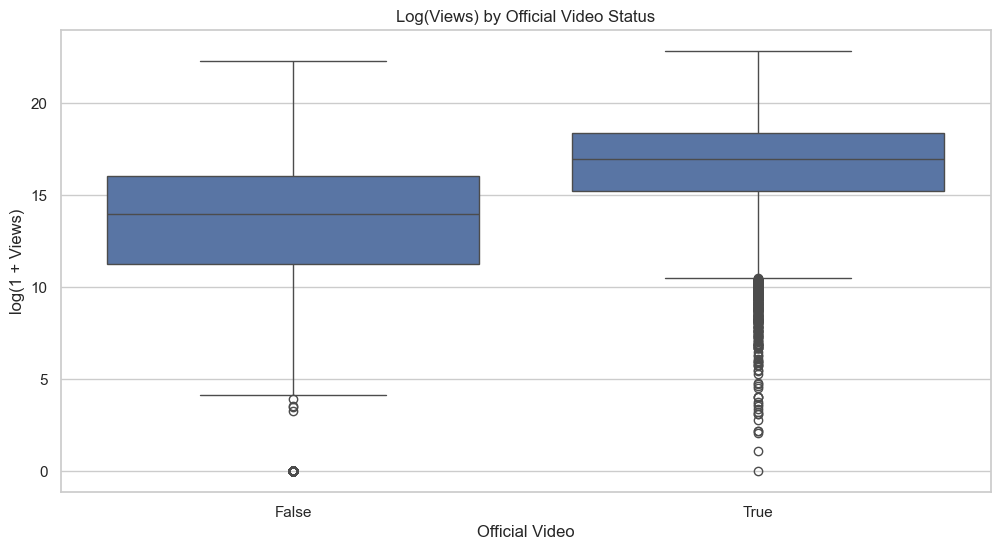

In [167]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="official_video",
    y=np.log1p(df["Views"])
)
plt.title("Log(Views) by Official Video Status")
plt.xlabel("Official Video")
plt.ylabel("log(1 + Views)")
plt.show()


#### 7.3 Engagement Metrics by Album Type

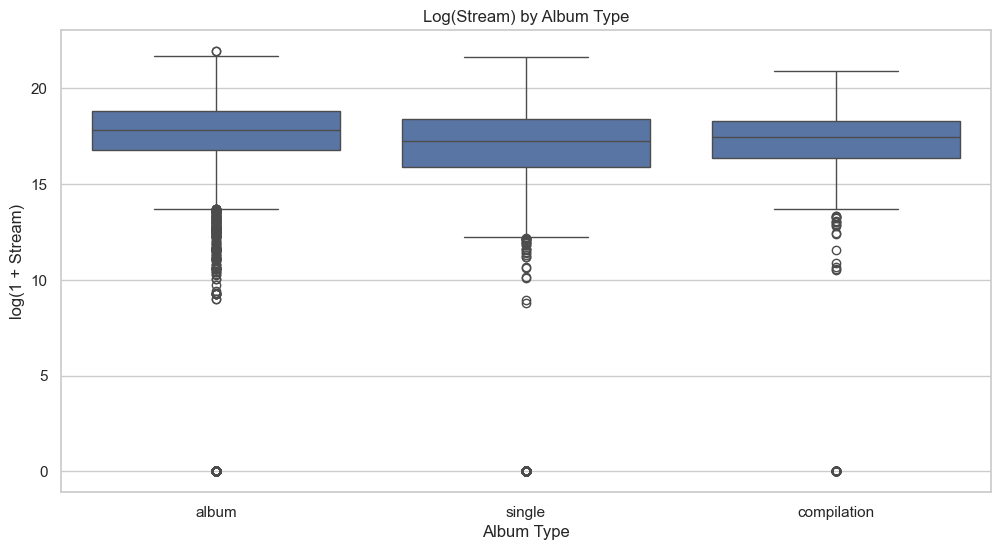

In [168]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Album_type",
    y=np.log1p(df["Stream"])
)
plt.title("Log(Stream) by Album Type")
plt.xlabel("Album Type")
plt.ylabel("log(1 + Stream)")
plt.show()


#### 7.4 Summary of Group Comparisons
**Key Insights:**

- Engagement metrics vary across platforms and content types.
- Songs with official videos generally receive higher engagement.
- Differences in audio feature distributions across platforms suggest
  platform-specific content preferences.

These findings support grouping, filtering, and interpretability features
in the final recommendation application.


### 8.0 Outliers and Interesting Cases
Outliers are important because extreme values can disproportionately influence
similarity measures, clustering results, and recommendation rankings.
This section identifies highly influential observations in key engagement metrics.

#### 8.1 Outliers in Engagement Metrics
The following engagement metrics are examined for extreme outliers:
- Comments
- Views
- Stream


In [169]:
outlier_metrics = ["Comments", "Views", "Stream"]


#### 8.2 Top 10 Outliers by Metric (Tables)
The tables below list the top 10 songs with the highest values for each engagement metric.


In [170]:
for metric in outlier_metrics:
    print(f"\nTop 10 Songs by {metric}")
    display(
        df.sort_values(metric, ascending=False)
          .loc[:, ["Artist", "Track", metric]]
          .head(10)
    )



Top 10 Songs by Comments


,Artist,Track,Comments
14482,BTS,Dynamite,16083138
14487,BTS,Butter,9131761
14486,BTS,Boy With Luv (feat. Halsey),6535721
15941,Halsey,Boy With Luv (feat. Halsey),6535719
8888,PSY,Gangnam Style (?????),5331537
17909,BLACKPINK,How You Like That,5130725
14006,Justin Bieber,Baby,4805805
1147,Luis Fonsi,Despacito,4252791
365,Daddy Yankee,Despacito,4252791
17906,BLACKPINK,Pink Venom,3637659



Top 10 Songs by Views


,Artist,Track,Views
1147,Luis Fonsi,Despacito,8079649362
365,Daddy Yankee,Despacito,8079646911
12385,Ed Sheeran,Shape of You,5908398479
14501,Charlie Puth,See You Again (feat. Charlie Puth),5773798407
12402,Wiz Khalifa,See You Again (feat. Charlie Puth),5773797147
20180,CoComelon,Wheels on the Bus,4898831101
10636,Mark Ronson,Uptown Funk (feat. Bruno Mars),4821016218
8888,PSY,Gangnam Style (?????),4679767471
9519,Maroon 5,Sugar,3817733132
12965,Katy Perry,Roar,3725748519



Top 10 Songs by Stream


,Artist,Track,Stream
15166,The Weeknd,Blinding Lights,3386520288
12385,Ed Sheeran,Shape of You,3362005201
19082,Lewis Capaldi,Someone You Loved,2634013335
17847,Post Malone,rockstar (feat. 21 Savage),2594926619
17848,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,2538329799
17356,Swae Lee,Sunflower - Spider-Man: Into the Spider-Verse,2538329799
13433,Drake,One Dance,2522431995
15939,Halsey,Closer,2456205158
16010,The Chainsmokers,Closer,2456205158
13960,Imagine Dragons,Believer,2369272335


#### 8.3 Bar Charts of Top 10 Outliers
Bar charts are used to visually highlight the dominance of extreme engagement values.


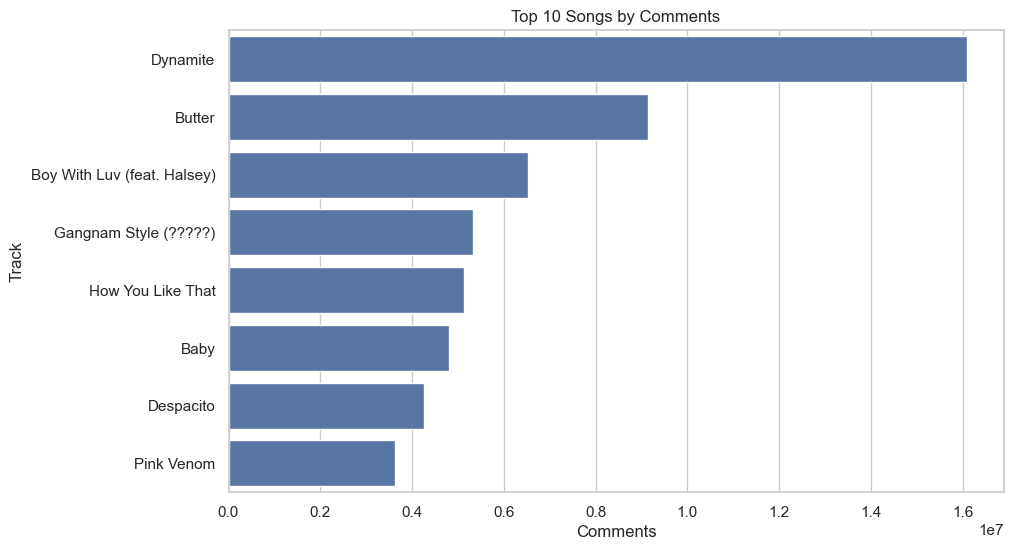

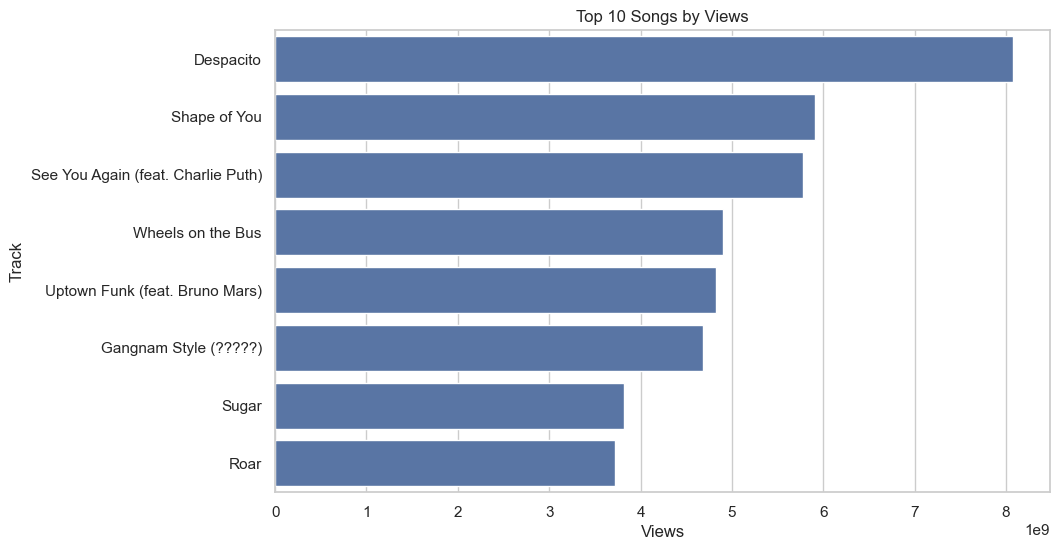

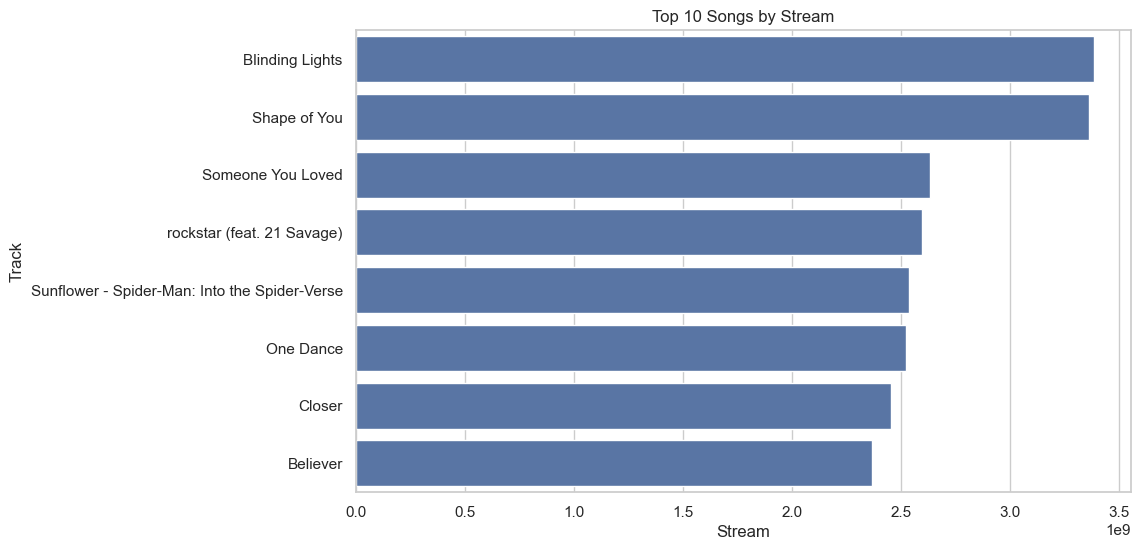

In [171]:
for metric in outlier_metrics:
    top10 = df.sort_values(metric, ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top10,
        x=metric,
        y="Track",
        orient="h"
    )
    plt.title(f"Top 10 Songs by {metric}")
    plt.xlabel(metric)
    plt.ylabel("Track")
    plt.show()


#### 8.4 Discussion on Outlier Handling (Conceptual)
**Observations:**

- Engagement metrics exhibit extreme long-tail distributions.
- A small number of songs dominate Comments, Views, and Stream counts.
- These outliers can significantly bias:
  - similarity computations
  - clustering assignments
  - recommendation rankings

**Implications:**

- Log transformation is recommended to reduce skewness.
- Additional strategies such as capping or weighting may be considered
  during preprocessing to limit the influence of extreme values.

### 9.0 EDA Summary
This section summarizes key findings from exploratory data analysis
and provides guidance for downstream preprocessing, clustering,
and application development.

#### 9.1 Key Findings from EDA
**Data Quality**
- No technical missing values (NaN) were detected.
- Semantic missing values were identified in selected categorical attributes.
- Duplicate records exist for Artist + Track combinations.

**Engagement Metrics**
- Views, Likes, Comments, and Stream are highly right-skewed.
- Log transformation significantly improves interpretability.
- Extreme outliers dominate popularity metrics.

**Audio Features**
- Most audio features are bounded between 0 and 1.
- Features are already approximately normalized and suitable for similarity analysis.
- Some features exhibit outliers but remain within valid ranges.

**Relationships**
- Strong positive relationships exist among engagement metrics.
- Audio features show weak correlations with engagement metrics.
- Platform and content type influence engagement patterns.

---
## Task 2: Preprocessing, Feature Engineering, and Data Transformation
**Team Member:** Kamil

This section implements the complete preprocessing pipeline to prepare the dataset for clustering and similarity-based recommendation. The pipeline includes data cleaning, feature engineering, encoding, scaling, and dimensionality reduction to create robust feature representations.

### Task 2.1: Data Preprocessing

Preprocessing is essential to ensure data quality and consistency before clustering and recommendation tasks. This step standardizes column names, removes duplicates, handles missing values, filters irrelevant columns, and ensures correct data types for downstream analysis.

#### 2.1.1 Load Dataset and Standardize Column Names

In [172]:
df_raw = pd.read_csv("Spotify dataset export 2025-12-31 15-24-26.csv")

df_clean = df_raw.copy()

print(f"Original dataset shape: {df_clean.shape}")
print(f"Original columns: {list(df_clean.columns)}")

# Standardize column names: lowercase and replace spaces with underscores
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

print(f"\nStandardized columns: {list(df_clean.columns)}")

Original dataset shape: (20594, 24)
Original columns: ['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Title', 'Channel', 'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream', 'EnergyLiveness', 'most_playedon']

Standardized columns: ['artist', 'track', 'album', 'album_type', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'title', 'channel', 'views', 'likes', 'comments', 'licensed', 'official_video', 'stream', 'energyliveness', 'most_playedon']


#### 2.1.2 Remove Duplicate Records

In [173]:
# Check for duplicates based on artist + track (as identified in EDA)
before_dup = len(df_clean)
print(f"Records before deduplication: {before_dup}")

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['artist', 'track'], keep='first')

after_dup = len(df_clean)
print(f"Records after deduplication: {after_dup}")
print(f"Duplicates removed: {before_dup - after_dup}")

Records before deduplication: 20594
Records after deduplication: 20512
Duplicates removed: 82


#### 2.1.3 Handle Missing Values

In [174]:
# Check for technical missing values (NaN)
print("Technical missing values (NaN):")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Handle semantic missing values in categorical columns
categorical_cols = ['artist', 'track', 'album', 'album_type', 'title', 'channel', 'most_playedon']
semantic_placeholders = ['0', '', 'none', 'nan', 'null']

for col in categorical_cols:
    if col in df_clean.columns:
        # Replace semantic missing values with 'unknown'
        mask = df_clean[col].astype(str).str.strip().str.lower().isin(semantic_placeholders)
        df_clean.loc[mask, col] = 'unknown'

# Impute numeric columns with median (if any NaN exists)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed {col} with median: {median_val}")

print("\nMissing values after handling:")
print(df_clean.isnull().sum().sum())

Technical missing values (NaN):
Series([], dtype: int64)

Missing values after handling:
0


#### 2.1.4 Remove Irrelevant Columns

In [175]:
# Identify metadata columns to keep separately (not for clustering/similarity)
metadata_cols = ['artist', 'track', 'album', 'title', 'channel', 'url_spotify', 'uri', 'url_youtube']

# Identify columns that are not useful for similarity/clustering
irrelevant_patterns = ['url', 'uri', 'description', 'licensed', 'official_video']
cols_to_drop = []

for col in df_clean.columns:
    for pattern in irrelevant_patterns:
        if pattern in col.lower():
            cols_to_drop.append(col)
            break

# Remove duplicates from list
cols_to_drop = list(set(cols_to_drop))

print(f"Columns to drop (not useful for clustering): {cols_to_drop}")

# Keep these columns for later reference but don't use in feature matrix
df_clean_features = df_clean.drop(columns=cols_to_drop, errors='ignore')

print(f"\nShape after dropping irrelevant columns: {df_clean_features.shape}")
print(f"Remaining columns: {list(df_clean_features.columns)}")

Columns to drop (not useful for clustering): ['official_video', 'licensed']

Shape after dropping irrelevant columns: (20512, 22)
Remaining columns: ['artist', 'track', 'album', 'album_type', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'title', 'channel', 'views', 'likes', 'comments', 'stream', 'energyliveness', 'most_playedon']


#### 2.1.5 Ensure Correct Data Types

In [176]:
# Identify audio features that should be numeric
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

# Ensure they are float type
for col in audio_features:
    if col in df_clean_features.columns:
        df_clean_features[col] = pd.to_numeric(df_clean_features[col], errors='coerce')

# Convert categorical columns to category dtype for efficiency
categorical_features = ['key', 'album_type', 'most_playedon']
for col in categorical_features:
    if col in df_clean_features.columns:
        df_clean_features[col] = df_clean_features[col].astype('category')

print("Data types after correction:")
print(df_clean_features.dtypes)

Data types after correction:
artist                object
track                 object
album                 object
album_type          category
danceability         float64
energy               float64
loudness             float64
speechiness          float64
acousticness         float64
instrumentalness     float64
liveness             float64
valence              float64
tempo                float64
duration_min         float64
title                 object
channel               object
views                  int64
likes                  int64
comments               int64
stream                 int64
energyliveness       float64
most_playedon       category
dtype: object


### Task 2.2: Feature Engineering

Feature engineering enhances the dataset by creating meaningful representations that improve clustering quality. This includes identifying audio and categorical features, encoding categorical variables, and creating derived features that capture musical characteristics useful for similarity-based recommendation.

#### 2.2.1 Identify Numeric and Categorical Features

In [177]:
# Identify numeric audio features automatically
audio_feature_candidates = ['danceability', 'energy', 'loudness', 'speechiness', 
                            'acousticness', 'instrumentalness', 'liveness', 
                            'valence', 'tempo', 'duration_ms']

numeric_features = [col for col in audio_feature_candidates if col in df_clean_features.columns]

print(f"Numeric audio features identified: {numeric_features}")
print(f"Count: {len(numeric_features)}")

# Identify categorical features that exist in the dataset
categorical_feature_candidates = ['album_type', 'most_playedon']
categorical_features = [col for col in categorical_feature_candidates 
                        if col in df_clean_features.columns]

print(f"\nCategorical features identified: {categorical_features}")
print(f"Count: {len(categorical_features)}")

# Show cardinality of categorical features
for col in categorical_features:
    unique_count = df_clean_features[col].nunique()
    print(f"  {col}: {unique_count} unique values")

Numeric audio features identified: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Count: 9

Categorical features identified: ['album_type', 'most_playedon']
Count: 2
  album_type: 3 unique values
  most_playedon: 2 unique values


#### 2.2.2 Encode Categorical Features

In [178]:
# One-hot encode categorical features
# For high cardinality features, keep only top N categories and group rest as 'other'

encoded_dfs = []
encoded_feature_names = []

for col in categorical_features:
    unique_count = df_clean_features[col].nunique()
    
    if unique_count <= 20:
        # Low cardinality: one-hot encode all categories
        encoded = pd.get_dummies(df_clean_features[col], prefix=col, drop_first=False)
        encoded_dfs.append(encoded)
        encoded_feature_names.extend(encoded.columns.tolist())
        print(f"One-hot encoded '{col}': {len(encoded.columns)} features")
    else:
        # High cardinality: keep top 20 and group rest as 'other'
        top_categories = df_clean_features[col].value_counts().head(20).index.tolist()
        df_clean_features[f'{col}_grouped'] = df_clean_features[col].apply(
            lambda x: x if x in top_categories else 'other'
        )
        encoded = pd.get_dummies(df_clean_features[f'{col}_grouped'], prefix=col, drop_first=False)
        encoded_dfs.append(encoded)
        encoded_feature_names.extend(encoded.columns.tolist())
        print(f"One-hot encoded '{col}' (grouped): {len(encoded.columns)} features")

# Combine all encoded features
if encoded_dfs:
    df_encoded = pd.concat(encoded_dfs, axis=1)
    print(f"\nTotal encoded categorical features: {len(encoded_feature_names)}")
else:
    df_encoded = pd.DataFrame()
    print("\nNo categorical features to encode.")

One-hot encoded 'album_type': 3 features
One-hot encoded 'most_playedon': 2 features

Total encoded categorical features: 5


#### 2.2.3 Create Engineered Features

In [179]:
# Create engineered features that capture musical characteristics
engineered_features = []

# 1. Mood Score: combination of energy and valence
if 'energy' in df_clean_features.columns and 'valence' in df_clean_features.columns:
    df_clean_features['mood_score'] = df_clean_features['energy'] * df_clean_features['valence']
    engineered_features.append('mood_score')
    print("Created: mood_score = energy × valence")

# 2. Rhythm Score: combination of danceability and tempo (normalized)
if 'danceability' in df_clean_features.columns and 'tempo' in df_clean_features.columns:
    # Normalize tempo to [0, 1] range for combination
    tempo_normalized = (df_clean_features['tempo'] - df_clean_features['tempo'].min()) / \
                       (df_clean_features['tempo'].max() - df_clean_features['tempo'].min())
    df_clean_features['rhythm_score'] = df_clean_features['danceability'] * tempo_normalized
    engineered_features.append('rhythm_score')
    print("Created: rhythm_score = danceability × tempo_normalized")

# 3. Acoustic Profile: difference between acousticness and instrumentalness
if 'acousticness' in df_clean_features.columns and 'instrumentalness' in df_clean_features.columns:
    df_clean_features['acoustic_profile'] = df_clean_features['acousticness'] - df_clean_features['instrumentalness']
    engineered_features.append('acoustic_profile')
    print("Created: acoustic_profile = acousticness - instrumentalness")

print(f"\nTotal engineered features: {len(engineered_features)}")

Created: mood_score = energy × valence
Created: rhythm_score = danceability × tempo_normalized
Created: acoustic_profile = acousticness - instrumentalness

Total engineered features: 3


#### 2.2.4 Assemble Final Feature Set

In [180]:
# Combine all features: numeric + engineered + encoded categorical
all_feature_names = numeric_features + engineered_features + encoded_feature_names

df_numeric = df_clean_features[numeric_features].copy().reset_index(drop=True)

if engineered_features:
    df_engineered = df_clean_features[engineered_features].copy().reset_index(drop=True)
else:
    df_engineered = pd.DataFrame()

# Reset index for encoded features to ensure alignment
if not df_encoded.empty:
    df_encoded = df_encoded.reset_index(drop=True)

# Combine all features
feature_dfs = [df_numeric]
if not df_engineered.empty:
    feature_dfs.append(df_engineered)
if not df_encoded.empty:
    feature_dfs.append(df_encoded)

df_features_final = pd.concat(feature_dfs, axis=1)

# Handle any remaining NaN values with multiple strategies
# First try median, then mean, then 0 for any remaining NaNs
for col in df_features_final.columns:
    if df_features_final[col].isna().any():
        # Try median first
        median_val = df_features_final[col].median()
        if pd.notna(median_val):
            df_features_final[col].fillna(median_val, inplace=True)
        else:
            # If median is NaN (all values are NaN), use 0
            df_features_final[col].fillna(0, inplace=True)

# Final safety check - replace any remaining NaN with 0
df_features_final = df_features_final.fillna(0)

print("Final Feature Set Summary:")
print(f"  Numeric features: {len(numeric_features)}")
print(f"  Engineered features: {len(engineered_features)}")
print(f"  Encoded categorical features: {len(encoded_feature_names)}")
print(f"  Total features: {df_features_final.shape[1]}")
print(f"  Total samples: {df_features_final.shape[0]}")
print(f"\nFeature names: {list(df_features_final.columns)}")

Final Feature Set Summary:
  Numeric features: 9
  Engineered features: 3
  Encoded categorical features: 5
  Total features: 17
  Total samples: 20512

Feature names: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'mood_score', 'rhythm_score', 'acoustic_profile', 'album_type_album', 'album_type_compilation', 'album_type_single', 'most_playedon_Spotify', 'most_playedon_Youtube']


### Task 2.3: Data Transformation

Data transformation standardizes feature scales and reduces dimensionality for visualization. Scaling ensures that all features contribute equally to distance-based similarity metrics, while PCA provides low-dimensional projections for exploratory visualization and cluster interpretation.

#### 2.3.1 Prepare Feature Matrix and Metadata

In [181]:
# Extract metadata columns separately (identifiers for later reference)
metadata_column_names = ['artist', 'track', 'album']
df_metadata = df_clean_features[metadata_column_names].copy().reset_index(drop=True)

# Check for NaN values in dataframe before converting to numpy array
print(f"Feature matrix shape: {df_features_final.shape}")
print(f"Metadata shape: {df_metadata.shape}")
print(f"\nChecking for NaN values in feature dataframe: {df_features_final.isna().sum().sum()}")

# If NaN values exist, show which columns have them
if df_features_final.isna().sum().sum() > 0:
    print("\nColumns with NaN values:")
    for col in df_features_final.columns:
        nan_count = df_features_final[col].isna().sum()
        if nan_count > 0:
            print(f"  {col}: {nan_count} NaN values")

# Convert to numpy array (all numeric now, NaN-free)
X_features = df_features_final.astype(float).values
print(f"\nConverted to numpy array: {X_features.shape}, dtype: {X_features.dtype}")

Feature matrix shape: (20512, 17)
Metadata shape: (20512, 3)

Checking for NaN values in feature dataframe: 0

Converted to numpy array: (20512, 17), dtype: float64


#### 2.3.2 Scale Features Using StandardScaler

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Mean of scaled features (should be ~0): {X_scaled.mean():.6f}")
print(f"Std of scaled features (should be ~1): {X_scaled.std():.6f}")
print(f"NaN check after scaling: {np.isnan(X_scaled).sum()}")

Scaled feature matrix shape: (20512, 17)
Mean of scaled features (should be ~0): 0.000000
Std of scaled features (should be ~1): 1.000000
NaN check after scaling: 0


#### 2.3.3 Apply PCA for Dimensionality Reduction (2D and 3D)

In [183]:
from sklearn.decomposition import PCA

# Apply PCA for 2D projection
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"2D PCA shape: {X_pca_2d.shape}")
print(f"2D PCA explained variance: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Apply PCA for 3D projection
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\n3D PCA shape: {X_pca_3d.shape}")
print(f"3D PCA explained variance: {pca_3d.explained_variance_ratio_.sum():.4f}")

2D PCA shape: (20512, 2)
2D PCA explained variance: 0.3769

3D PCA shape: (20512, 3)
3D PCA explained variance: 0.4857


### Task 2.4: Export Outputs for Clustering & Recommendation

This section exports all processed datasets and feature matrices required by other team members for clustering algorithms and recommendation system development.

#### 2.4.1 Save Cleaned Data

In [184]:
# Combine metadata with raw features (before scaling) for reference
df_cleaned_export = pd.concat([df_metadata, df_features_final], axis=1)

# Save cleaned data
df_cleaned_export.to_csv('cleaned_data.csv', index=False)
print(f"Saved: cleaned_data.csv (shape: {df_cleaned_export.shape})")

# Preview
print("\nPreview of cleaned_data.csv:")
df_cleaned_export.head()

Saved: cleaned_data.csv (shape: (20512, 20))

Preview of cleaned_data.csv:


,artist,track,album,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,mood_score,rhythm_score,acoustic_profile,album_type_album,album_type_compilation,album_type_single,most_playedon_Spotify,most_playedon_Youtube
0,Gorillaz,Feel Good Inc.,Demon Days,0.818,0.705,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,0.544260,0.465712,0.006030,True,False,False,True,False
1,Gorillaz,Rhinestone Eyes,Plastic Beach,0.676,0.703,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,0.598956,0.257657,0.086213,True,False,False,True,False
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),0.695,0.923,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,0.508573,0.308457,-0.004400,False,False,True,True,False
3,Gorillaz,On Melancholy Hill,Plastic Beach,0.689,0.739,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,0.427142,0.340924,-0.508985,True,False,False,True,False
4,Gorillaz,Clint Eastwood,Gorillaz,0.663,0.694,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,0.364350,0.457542,0.025300,True,False,False,False,True


#### 2.4.2 Save Scaled Feature Matrix

In [185]:
# Save scaled features as numpy array (efficient for ML algorithms)
np.save('features_scaled.npy', X_scaled)
print(f"✓ Saved: features_scaled.npy (shape: {X_scaled.shape})")

df_scaled = pd.DataFrame(X_scaled, columns=df_features_final.columns)

# Preview
print("\nPreview of scaled features:")
df_scaled.head()

✓ Saved: features_scaled.npy (shape: (20512, 17))

Preview of scaled features:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,mood_score,rhythm_score,acoustic_profile,album_type_album,album_type_compilation,album_type_single,most_playedon_Spotify,most_playedon_Youtube
0,1.196330,0.325710,0.214327,0.714081,-0.989123,-0.277843,2.487604,0.986146,0.607648,0.874164,1.562037,-0.768654,0.622301,-0.198157,-0.564063,0.556702,-0.556702
1,0.338340,0.316374,0.400575,-0.592955,-0.714567,-0.286333,-0.872849,1.312010,-0.939216,1.129542,-0.471570,-0.499723,0.622301,-0.198157,-0.564063,0.556702,-0.556702
2,0.453142,1.343339,0.806914,-0.397077,-0.869778,-0.047550,-0.459537,0.085946,-0.424034,0.707540,0.024967,-0.803636,-1.606940,-0.198157,1.772851,0.556702,-0.556702
3,0.416889,0.484423,0.401653,-0.630349,-1.018295,2.340127,-0.767890,0.195925,-0.004910,0.327336,0.342317,-2.495999,0.622301,-0.198157,-0.564063,0.556702,-0.556702
4,0.259792,0.274361,-0.205594,0.660660,-0.929905,-0.289883,-0.733497,-0.019960,1.600454,0.034157,1.482177,-0.704023,0.622301,-0.198157,-0.564063,-1.796292,1.796292


#### 2.4.4 Save Feature List

In [186]:
# Save feature list
with open('feature_list.txt', 'w') as f:
    for feature in df_features_final.columns:
        f.write(f"{feature}\n")

print(f"✓ Saved: feature_list.txt ({len(df_features_final.columns)} features)")

# Display feature list
print("\nFinal feature list:")
for i, feature in enumerate(df_features_final.columns, 1):
    print(f"  {i}. {feature}")

✓ Saved: feature_list.txt (17 features)

Final feature list:
  1. danceability
  2. energy
  3. loudness
  4. speechiness
  5. acousticness
  6. instrumentalness
  7. liveness
  8. valence
  9. tempo
  10. mood_score
  11. rhythm_score
  12. acoustic_profile
  13. album_type_album
  14. album_type_compilation
  15. album_type_single
  16. most_playedon_Spotify
  17. most_playedon_Youtube


### Task 2.5: Summary and Final Verification

This section provides a comprehensive summary of all preprocessing, feature engineering, and transformation steps completed in Task 2.

---
## Task 3: Feature Selection, Clustering, and Recommendation System

This section implements feature selection to identify the most important features for clustering, applies multiple clustering algorithms to group similar songs, and builds a recommendation system that suggests similar songs based on cluster assignments and feature similarity.

### Task 3.1: Feature Selection

Feature selection reduces dimensionality by identifying the most relevant features for clustering. This improves clustering performance, reduces computational cost, and enhances interpretability.

#### 3.1.1 Load Preprocessed Data

In [187]:
# Load feature names
with open('feature_list.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

print(f"Loaded scaled features: {X_scaled.shape}")
print(f"Loaded metadata: {df_metadata.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}...")  # Show first 10

Loaded scaled features: (20512, 17)
Loaded metadata: (20512, 3)
Number of features: 17

Feature names: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'mood_score']...


#### 3.1.3 Correlation Analysis for Feature Selection

Identify and remove highly correlated features to reduce redundancy.

In [188]:
X_var_selected = X_scaled
selected_features_var = feature_names.copy()

# Calculate correlation matrix
corr_matrix = np.corrcoef(X_var_selected.T)

# Find pairs of features with correlation > 0.9
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix[i, j]) > 0.9:
            high_corr_pairs.append((
                selected_features_var[i],
                selected_features_var[j],
                corr_matrix[i, j]
            ))

print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|correlation| > 0.9):")
for feat1, feat2, corr in high_corr_pairs[:10]:  # Show first 10
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")

# Remove one feature from each highly correlated pair
features_to_remove = set()
for feat1, feat2, corr in high_corr_pairs:
    if feat1 not in features_to_remove:
        features_to_remove.add(feat2)

selected_features_final = [f for f in selected_features_var if f not in features_to_remove]

# Create final feature matrix
feature_indices = [feature_names.index(f) for f in selected_features_final]
X_selected = X_scaled[:, feature_indices]

print(f"\n\nFinal Feature Selection Results:")
print(f"  After variance threshold: {len(selected_features_var)}")
print(f"  Features removed due to high correlation: {len(features_to_remove)}")
print(f"  Final selected features: {len(selected_features_final)}")
print(f"  Final feature matrix shape: {X_selected.shape}")

Found 2 highly correlated feature pairs (|correlation| > 0.9):
  album_type_album <-> album_type_single: -0.906
  most_playedon_Spotify <-> most_playedon_Youtube: -1.000


Final Feature Selection Results:
  After variance threshold: 17
  Features removed due to high correlation: 2
  Final selected features: 15
  Final feature matrix shape: (20512, 15)


In [189]:
# Display final selected features
print("Final Selected Features:")
for i, feature in enumerate(selected_features_final, 1):
    print(f"  {i}. {feature}")

Final Selected Features:
  1. danceability
  2. energy
  3. loudness
  4. speechiness
  5. acousticness
  6. instrumentalness
  7. liveness
  8. valence
  9. tempo
  10. mood_score
  11. rhythm_score
  12. acoustic_profile
  13. album_type_album
  14. album_type_compilation
  15. most_playedon_Spotify


### Task 3.2: Clustering

Apply multiple clustering algorithms to group similar songs and evaluate their performance.

#### 3.2.1 Determine Optimal Number of Clusters using Elbow Method

Elbow Method - Inertia values:
  k=2: 253267.84
  k=3: 228566.81
  k=4: 209415.54
  k=5: 196738.58
  k=6: 179213.84
  k=7: 168929.07
  k=8: 160344.89
  k=9: 153492.52
  k=10: 147832.90


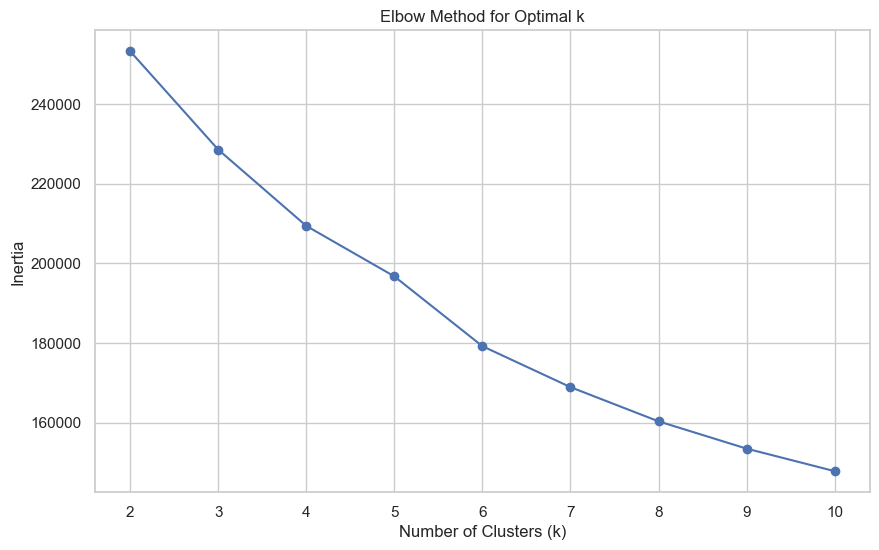

In [190]:
from sklearn.cluster import KMeans

# Calculate inertia for different numbers of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_selected)
    inertias.append(kmeans.inertia_)
    
print("Elbow Method - Inertia values:")
for k, inertia in zip(K_range, inertias):
    print(f"  k={k}: {inertia:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

#### 3.2.2 Silhouette Score Analysis

Silhouette Scores:
  k=2: 0.2262
  k=3: 0.1788
  k=4: 0.1345
  k=5: 0.1331
  k=6: 0.1540
  k=7: 0.1556
  k=8: 0.1603
  k=9: 0.1592
  k=10: 0.1491


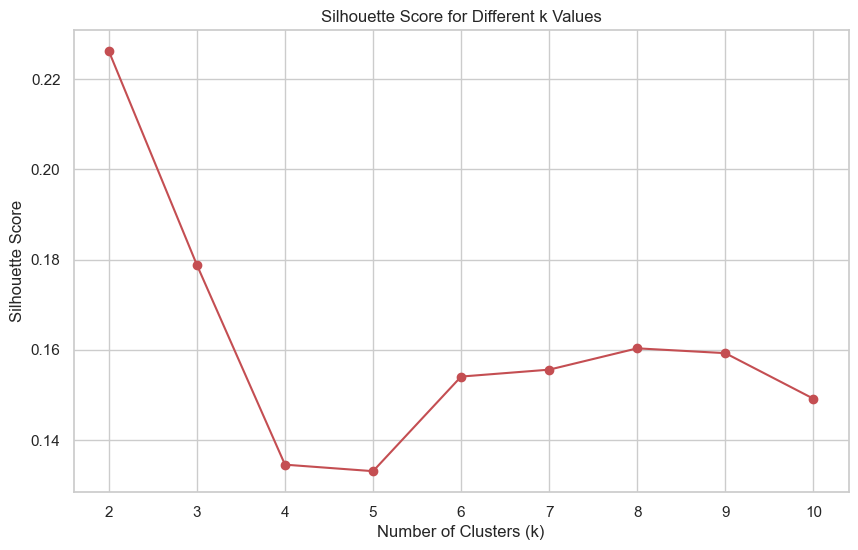



Optimal number of clusters based on Silhouette Score: 2


In [191]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_selected)
    score = silhouette_score(X_selected, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k Values')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Find optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n\nOptimal number of clusters based on Silhouette Score: {optimal_k}")

#### 3.2.3 Apply K-Means Clustering with Optimal k

In [192]:
# Apply K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels_kmeans = kmeans_final.fit_predict(X_selected)

# Add cluster labels to metadata
df_metadata['cluster_kmeans'] = cluster_labels_kmeans

# Save for Streamlit 
df_metadata.to_csv("cleaned_data_with_cluster.csv", index=False)  # contains songs + cluster
np.save("X_selected.npy", X_selected)                             # feature matrix used for clustering
np.save("X_normed.npy", X_selected / (np.linalg.norm(X_selected, axis=1, keepdims=True) + 1e-12))  # normalized for cosine sim

print(f"K-Means Clustering Results (k={optimal_k}):")
print(f"  Total songs: {len(cluster_labels_kmeans)}")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels_kmeans).value_counts().sort_index())

# Calculate final silhouette score
final_silhouette = silhouette_score(X_selected, cluster_labels_kmeans)
print(f"\n\nFinal Silhouette Score: {final_silhouette:.4f}")


K-Means Clustering Results (k=2):
  Total songs: 20512

Cluster distribution:
0    15287
1     5225
Name: count, dtype: int64


Final Silhouette Score: 0.2262


#### 3.2.4 K-Means Stability Check (ARI)

We check if the KMeans is stable using ARI. We follow this simple rule of thumb:
- Mean ARI >= 0.8 : Very stable clusters
- 0.5 - 0.8: Moderate
- <0.5: Unstable

In [193]:
from sklearn.metrics import adjusted_rand_score

X_final = X_selected   
k = optimal_k          

seeds = [0, 1, 2, 3, 4]  # 5 runs
labels_by_seed = {}

# Run KMeans multiple times with different random seeds
for s in seeds:
    km = KMeans(n_clusters=k, random_state=s, n_init=10)
    labels_by_seed[s] = km.fit_predict(X_final)

# Compute pairwise ARI between all runs
ari_rows = []
seed_list = list(labels_by_seed.keys())

for i in range(len(seed_list)):
    for j in range(i + 1, len(seed_list)):
        s1, s2 = seed_list[i], seed_list[j]
        ari = adjusted_rand_score(labels_by_seed[s1], labels_by_seed[s2])
        ari_rows.append({"seed_1": s1, "seed_2": s2, "ARI": ari})

ari_df = pd.DataFrame(ari_rows).sort_values("ARI", ascending=False)

print("KMeans Stability Check (Adjusted Rand Index, ARI)")
print(f"Chosen K = {k}")
print(f"Mean ARI: {ari_df['ARI'].mean():.4f}")
print(f"Min  ARI: {ari_df['ARI'].min():.4f}")
print(f"Max  ARI: {ari_df['ARI'].max():.4f}")
display(ari_df)

KMeans Stability Check (Adjusted Rand Index, ARI)
Chosen K = 2
Mean ARI: 0.9904
Min  ARI: 0.9803
Max  ARI: 0.9973


,seed_1,seed_2,ARI
8,2,4,0.997317
2,0,3,0.997106
3,0,4,0.993810
1,0,2,0.993192
9,3,4,0.991336
7,2,3,0.990719
4,1,2,0.989509
6,1,4,0.988482
0,0,1,0.982735
5,1,3,0.980274


#### 3.2.5 Visualize Clusters using PCA

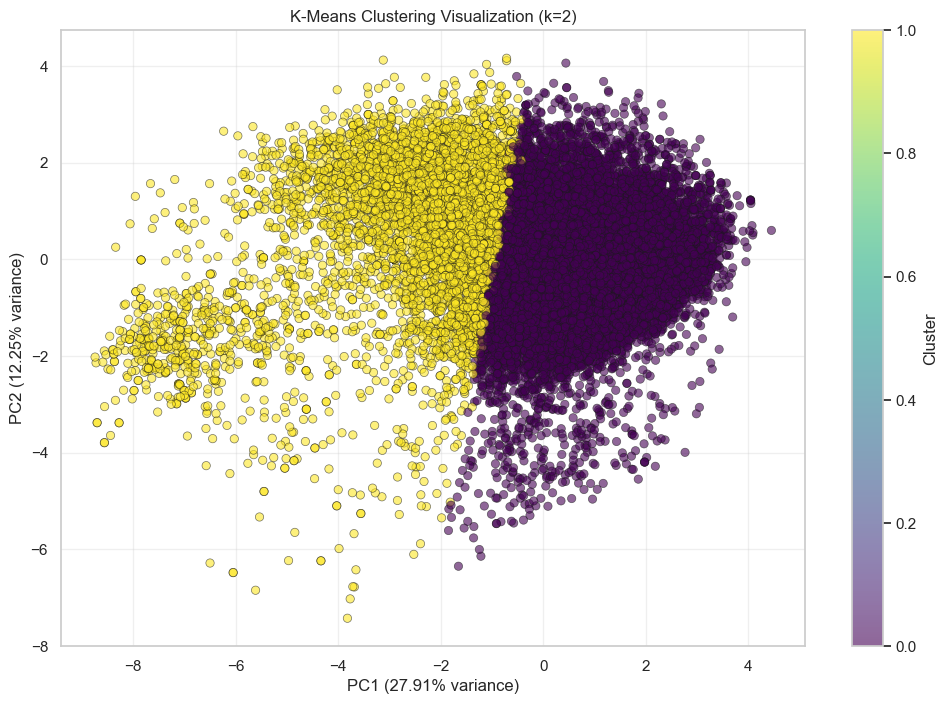

Total variance explained by 2 PCs: 40.17%


In [194]:
from sklearn.decomposition import PCA

# Apply PCA for 2D visualization
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_selected)

# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1], 
                     c=cluster_labels_kmeans, 
                     cmap='viridis', 
                     alpha=0.6, 
                     edgecolors='k',
                     linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'K-Means Clustering Visualization (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total variance explained by 2 PCs: {pca_viz.explained_variance_ratio_.sum():.2%}")

#### 3.2.6 Analyze Cluster Characteristics

Cluster Profiles (Mean Audio Feature Values):
                danceability  energy  valence    tempo  acousticness  \
cluster_kmeans                                                         
0                      0.664   0.722    0.597  123.830         0.177   
1                      0.490   0.382    0.333  111.025         0.625   

                instrumentalness  loudness  
cluster_kmeans                              
0                          0.026    -6.156  
1                          0.144   -12.112  


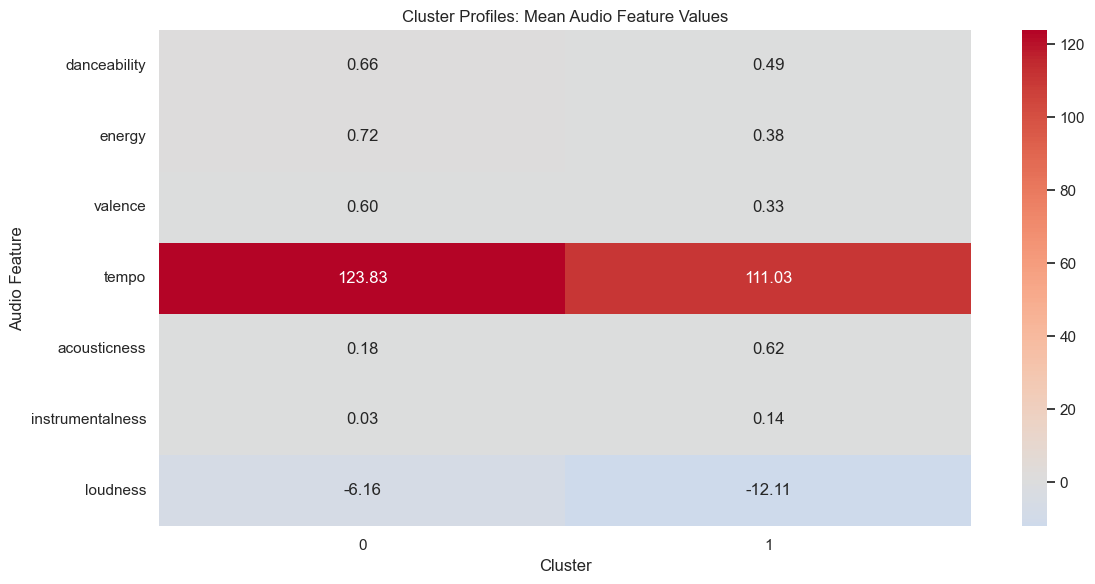

In [195]:
# Load original cleaned data to get audio features
df_cleaned = pd.read_csv('cleaned_data.csv')
df_cleaned['cluster_kmeans'] = cluster_labels_kmeans

# Define audio features to analyze
audio_features_analyze = ['danceability', 'energy', 'valence', 'tempo', 
                          'acousticness', 'instrumentalness', 'loudness']

# Calculate mean values for each cluster
cluster_profiles = df_cleaned.groupby('cluster_kmeans')[audio_features_analyze].mean()

print("Cluster Profiles (Mean Audio Feature Values):")
print(cluster_profiles.round(3))

# Visualize cluster profiles with heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='coolwarm', center=0.5)
plt.title('Cluster Profiles: Mean Audio Feature Values')
plt.xlabel('Cluster')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

In [196]:
# Show sample songs from each cluster
print("\n\nSample Songs from Each Cluster:")
for cluster_id in sorted(df_cleaned['cluster_kmeans'].unique()):
    cluster_songs = df_cleaned[df_cleaned['cluster_kmeans'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_songs)} songs) ---")
    sample = cluster_songs[['artist', 'track']].head(5)
    for idx, row in sample.iterrows():
        print(f"  • {row['artist']} - {row['track']}")



Sample Songs from Each Cluster:

--- Cluster 0 (15287 songs) ---
  • Gorillaz - Feel Good Inc.
  • Gorillaz - Rhinestone Eyes
  • Gorillaz - New Gold (feat. Tame Impala and Bootie Brown)
  • Gorillaz - On Melancholy Hill
  • Gorillaz - Clint Eastwood

--- Cluster 1 (5225 songs) ---
  • Red Hot Chili Peppers - Under the Bridge
  • Metallica - Nothing Else Matters (Remastered)
  • Coldplay - Sparks
  • Coldplay - The Scientist
  • Coldplay - Fix You


#### 3.2.7 Compare Alternative Clustering Algorithms

In [197]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=10)
cluster_labels_dbscan = dbscan.fit_predict(X_selected)

# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
cluster_labels_hierarchical = hierarchical.fit_predict(X_selected)

# Store all clustering results
clustering_results = {
    'K-Means': cluster_labels_kmeans,
    'DBSCAN': cluster_labels_dbscan,
    'Hierarchical': cluster_labels_hierarchical
}

# Evaluate each algorithm
print("Clustering Algorithm Comparison:\n")
print(f"{'Algorithm':<15} {'Silhouette':<12} {'Davies-Bouldin':<17} {'Calinski-Harabasz':<20} {'# Clusters'}")
print("-" * 80)

for name, labels in clustering_results.items():
    # Skip noise points for DBSCAN (labeled as -1)
    valid_mask = labels != -1
    
    if valid_mask.sum() < 2:
        print(f"{name:<15} {'N/A':<12} {'N/A':<17} {'N/A':<20} {len(set(labels))}")
        continue
    
    X_valid = X_selected[valid_mask]
    labels_valid = labels[valid_mask]
    
    # Calculate metrics
    n_clusters = len(set(labels_valid))
    
    if n_clusters > 1:
        sil_score = silhouette_score(X_valid, labels_valid)
        db_score = davies_bouldin_score(X_valid, labels_valid)
        ch_score = calinski_harabasz_score(X_valid, labels_valid)
        print(f"{name:<15} {sil_score:<12.4f} {db_score:<17.4f} {ch_score:<20.2f} {n_clusters}")
    else:
        print(f"{name:<15} {'N/A':<12} {'N/A':<17} {'N/A':<20} {n_clusters}")

# Show cluster distribution for each algorithm
print("\n\nCluster Distribution by Algorithm:")
for name, labels in clustering_results.items():
    print(f"\n{name}:")
    print(pd.Series(labels).value_counts().sort_index())

Clustering Algorithm Comparison:

Algorithm       Silhouette   Davies-Bouldin    Calinski-Harabasz    # Clusters
--------------------------------------------------------------------------------
K-Means         0.2262       1.8341            4406.39              2
DBSCAN          0.3484       1.2589            1633.41              2
Hierarchical    0.2365       1.7208            3069.70              2


Cluster Distribution by Algorithm:

K-Means:
0    15287
1     5225
Name: count, dtype: int64

DBSCAN:
-1       81
 0    19674
 1      757
Name: count, dtype: int64

Hierarchical:
0    17792
1     2720
Name: count, dtype: int64


### Task 3.3: Recommendation System

Build a music recommendation system based on clustering results and feature similarity.

#### 3.3.1 Build Similarity Matrix

Calculate cosine similarity between all songs based on selected features.

In [198]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix
print("Calculating cosine similarity matrix...")
similarity_matrix = cosine_similarity(X_selected)
np.save('similarity_matrix.npy', similarity_matrix)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Matrix dimensions: {similarity_matrix.shape[0]} songs × {similarity_matrix.shape[1]} songs")
print(f"\nSample similarity values:")
print(f"  Min similarity: {similarity_matrix.min():.4f}")
print(f"  Max similarity: {similarity_matrix.max():.4f}")
print(f"  Mean similarity: {similarity_matrix.mean():.4f}")

Calculating cosine similarity matrix...
Similarity matrix shape: (20512, 20512)
Matrix dimensions: 20512 songs × 20512 songs

Sample similarity values:
  Min similarity: -0.9598
  Max similarity: 1.0000
  Mean similarity: 0.0087


#### 3.3.2 Create Recommendation Function

Implement a recommendation function that suggests similar songs based on clustering and similarity.

In [199]:
def recommend_songs(song_index, n_recommendations=10, cluster_weight=0.3, use_cluster_filter=True):
    # Get similarity scores for the input song
    similarity_scores = similarity_matrix[song_index].copy()
    
    # Get cluster of input song
    input_cluster = cluster_labels_kmeans[song_index]
    
    if use_cluster_filter:
        # Only consider songs from the same cluster
        cluster_mask = cluster_labels_kmeans == input_cluster
        similarity_scores[~cluster_mask] = -1  # Exclude other clusters
    else:
        # Boost similarity scores for songs in the same cluster
        cluster_mask = cluster_labels_kmeans == input_cluster
        similarity_scores[cluster_mask] *= (1 + cluster_weight)
    
    # Set self-similarity to -1 (exclude the input song itself)
    similarity_scores[song_index] = -1
    
    # Get top N most similar songs
    top_indices = np.argsort(similarity_scores)[::-1][:n_recommendations]
    
    # Create recommendations dataframe
    recommendations = pd.DataFrame({
        'artist': df_cleaned.iloc[top_indices]['artist'].values,
        'track': df_cleaned.iloc[top_indices]['track'].values,
        'similarity_score': similarity_scores[top_indices],
        'cluster': cluster_labels_kmeans[top_indices],
        'input_cluster': input_cluster
    })
    
    return recommendations


# Helper function to find song by name
def find_song_index(artist_name, track_name):
    """Find the index of a song by artist and track name."""
    mask = (df_cleaned['artist'].str.contains(artist_name, case=False, na=False)) & \
           (df_cleaned['track'].str.contains(track_name, case=False, na=False))
    
    matches = df_cleaned[mask]
    
    if len(matches) == 0:
        print(f"No songs found matching artist='{artist_name}' and track='{track_name}'")
        return None
    elif len(matches) > 1:
        print(f"Multiple matches found ({len(matches)}). Showing first 5:")
        print(matches[['artist', 'track']].head())
        return matches.index[0]
    else:
        return matches.index[0]

print("Recommendation functions created successfully!")

Recommendation functions created successfully!


#### 3.3.3 Test Recommendation System - Example 1

Test the recommendation system with a popular song.

In [200]:
# Pick a random song to test
test_idx = 100 

print("="*80)
print("RECOMMENDATION SYSTEM TEST - Example 1")
print("="*80)

# Show input song details
input_song = df_cleaned.iloc[test_idx]
print(f"\nInput Song:")
print(f"  Artist: {input_song['artist']}")
print(f"  Track: {input_song['track']}")
print(f"  Cluster: {cluster_labels_kmeans[test_idx]}")

# Get recommendations (within same cluster only)
print(f"\n\nTop 10 Recommendations (Same Cluster Only):")
recommendations = recommend_songs(test_idx, n_recommendations=10, use_cluster_filter=True)
print(recommendations.to_string(index=False))

RECOMMENDATION SYSTEM TEST - Example 1

Input Song:
  Artist: Michael Jackson
  Track: Billie Jean
  Cluster: 0


Top 10 Recommendations (Same Cluster Only):
                  artist                                      track  similarity_score  cluster  input_cluster
 Daryl Hall & John Oates            I Can't Go for That (No Can Do)          0.976854        0              0
           Fleetwood Mac                     Dreams - 2004 Remaster          0.973860        0              0
                  Prince                      I Wanna Be Your Lover          0.963571        0              0
      Harish Raghavendra Devathaiya Kandein (From "Kadhal Kondaen")          0.958384        0              0
                 Stromae                Alors on danse - Radio Edit          0.957387        0              0
             Benny Sings                             Big Brown Eyes          0.953234        0              0
Bob Marley & The Wailers                               Is This Love     

#### 3.3.4 Test Recommendation System - Example 2

Test with a specific song by searching for it.

In [201]:
# Show some available artists and tracks for testing
print("Sample artists and tracks available in the dataset:")
print(df_cleaned[['artist', 'track']].head(20))

artist_search = df_cleaned['artist'].iloc[0]  # Use first artist as example
track_search = df_cleaned['track'].iloc[0]    # Use first track as example

print(f"\n\n{'='*80}")
print("RECOMMENDATION SYSTEM TEST - Example 2")
print("="*80)

song_idx = find_song_index(artist_search, track_search)

if song_idx is not None:
    input_song = df_cleaned.iloc[song_idx]
    print(f"\nInput Song:")
    print(f"  Artist: {input_song['artist']}")
    print(f"  Track: {input_song['track']}")
    print(f"  Cluster: {cluster_labels_kmeans[song_idx]}")
    
    print(f"\n\nTop 10 Recommendations:")
    recommendations = recommend_songs(song_idx, n_recommendations=10, use_cluster_filter=True)
    print(recommendations.to_string(index=False))

Sample artists and tracks available in the dataset:
                   artist                                              track
0                Gorillaz                                     Feel Good Inc.
1                Gorillaz                                    Rhinestone Eyes
2                Gorillaz      New Gold (feat. Tame Impala and Bootie Brown)
3                Gorillaz                                 On Melancholy Hill
4                Gorillaz                                     Clint Eastwood
5                Gorillaz                                               DARE
6                Gorillaz  New Gold (feat. Tame Impala and Bootie Brown) ...
7                Gorillaz                 She's My Collar (feat. Kali Uchis)
8                Gorillaz                  Cracker Island (feat. Thundercat)
9                Gorillaz                                        Dirty Harry
10  Red Hot Chili Peppers                                    Californication
11  Red Hot Chili Pepper

#### 3.3.5 Evaluate Recommendation Quality

Assess recommendation diversity and cluster coherence.

Recommendation System Quality Metrics (100 random songs):

Average Similarity Score: 1.2269 ± 0.0365
Average Cluster Coherence: 100.00% ± 0.00%

Interpretation:
  • Higher similarity scores indicate better feature-based matches
  • Higher cluster coherence indicates recommendations stay within similar song groups


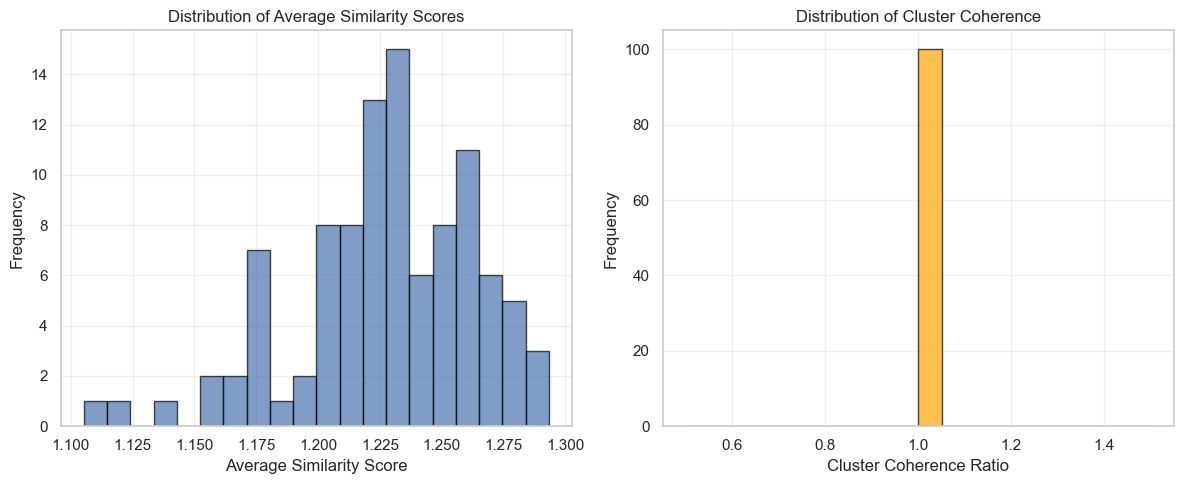

In [202]:
# Evaluate recommendation system on a sample of songs
np.random.seed(42)
sample_indices = np.random.choice(len(df_cleaned), size=100, replace=False)

# Metrics to track
avg_similarity_scores = []
cluster_coherence_ratios = []

for idx in sample_indices:
    recs = recommend_songs(idx, n_recommendations=10, use_cluster_filter=False)
    
    # Average similarity score
    avg_similarity_scores.append(recs['similarity_score'].mean())
    
    # Cluster coherence (% of recommendations from same cluster)
    same_cluster = (recs['cluster'] == recs['input_cluster'].iloc[0]).sum()
    cluster_coherence_ratios.append(same_cluster / len(recs))

print("Recommendation System Quality Metrics (100 random songs):\n")
print(f"Average Similarity Score: {np.mean(avg_similarity_scores):.4f} ± {np.std(avg_similarity_scores):.4f}")
print(f"Average Cluster Coherence: {np.mean(cluster_coherence_ratios):.2%} ± {np.std(cluster_coherence_ratios):.2%}")

print("\nInterpretation:")
print("  • Higher similarity scores indicate better feature-based matches")
print("  • Higher cluster coherence indicates recommendations stay within similar song groups")

# Visualize distribution of similarity scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(avg_similarity_scores, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Average Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Average Similarity Scores')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(cluster_coherence_ratios, bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Cluster Coherence Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Cluster Coherence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

From the experiment:
- The mean similarity score is 1.2269 with a standard deviation of 0.0365.
- As shown in the left histogram, most similarity scores are concentrated within a narrow range, indicating consistent recommendation quality across different query songs.
- The relatively small variance suggests that the system produces stable recommendations rather than highly fluctuating results.

Overall, these results indicate that the recommendation model is able to identify songs with high feature similarity, supporting the effectiveness of the underlying feature representation and similarity computation.
- The average cluster coherence is 100%, with zero variance.
- The right histogram shows that all evaluated recommendations have a coherence ratio of 1.0, meaning every recommended song lies within the same cluster as its corresponding query song.

This outcome confirms that the recommendation system strictly adheres to the clustering structure, ensuring that recommended songs remain within semantically similar groups identified by the K-Means clustering model.